# **Garbage Classification with Convolutional Neural Network (CNN)**

## **1. Import Libraries**

In [ ]:
import cv2
import urllib
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import os, random, glob
import matplotlib.pyplot as plt
from imutils import paths
from sklearn.utils import shuffle
from urllib.request import urlopen
from sklearn.metrics import confusion_matrix, classification_report
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout, SpatialDropout2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dir_path = '/content/drive/MyDrive/TrashType_Image_Dataset'

In [ ]:
target_size = (224, 224)

waste_labels = {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

In [ ]:
def load_datasets(path):

    x = []
    labels = []

    image_paths = sorted(list(paths.list_images(path)))

    for image_path in image_paths:
        img = cv2.imread(image_path)
        img = cv2.resize(img, target_size)
        x.append(img)

        label = image_path.split(os.path.sep)[-2]
        labels.append(waste_labels[label])

    x, labels = shuffle(x, labels, random_state=42)

    print(f"X size : {np.array(x).shape}")
    print(f"Label class number : {len(np.unique(labels))} Number of observations: {len(labels)}")

    return x, labels

In [ ]:
x, labels = load_datasets(dir_path)

X size : (2527, 224, 224, 3)
Label class number : 6 Number of observations: 2527


In [ ]:
input_shape = (np.array(x[0]).shape[0], np.array(x[0]).shape[1], 3)

print(f"Input Shape : {input_shape}")

Input Shape : (224, 224, 3)


## **2. Showing Examples from the Data Set**

In [ ]:
def visualize_img(image_batch, label_batch):
    plt.figure(figsize=(12, 12))
    for n in range(12):
        ax = plt.subplot(6, 6, n+1)
        plt.imshow(image_batch[n])
        plt.title(np.array(list(waste_labels.keys()))[to_categorical(labels, num_classes=6)[n]==1][0].title())
        plt.axis('off')

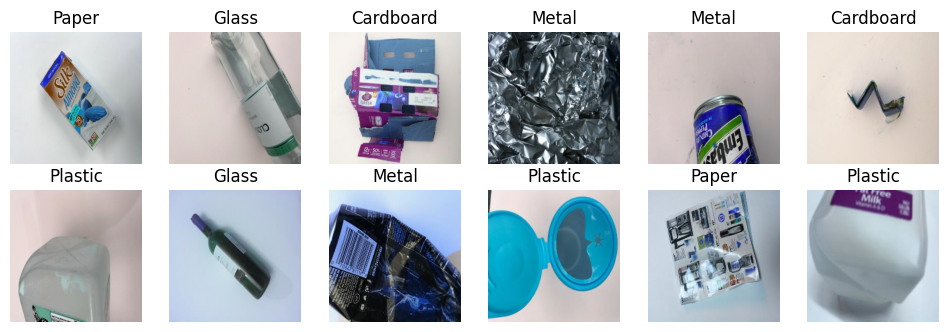

In [ ]:
visualize_img(x, labels)

## **3. Data Preparation**

In [ ]:
train = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    shear_range=0.15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
    validation_split=0.1,
)

test = ImageDataGenerator(rescale=1./255,
                          validation_split=0.1)

In [ ]:
train_generator = train.flow_from_directory(
    directory=dir_path,
    target_size=target_size,
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

test_generator = test.flow_from_directory(
    directory=dir_path,
    target_size=target_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

Found 2276 images belonging to 6 classes.
Found 251 images belonging to 6 classes.


## **4.Modeling**

- Sequential
- Convolution Layer (Convolotion Layer, Conv2D)
- Pooling Layer
- Activation Function Layer (Activation Layer)
- Flattening Layer
- Dense Layer
- Dropout Layer

In [ ]:
model = Sequential()

# Blok 1
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2, strides=2))
model.add(Dropout(0.25))

# Blok 2
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2, strides=2))
model.add(Dropout(0.25))

# Blok 3
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2, strides=2))
model.add(Dropout(0.25))

# Blok 4
model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2, strides=2))
model.add(Dropout(0.25))

# Classifier Head
model.add(GlobalAveragePooling2D())   # lebih ringan dari Flatten, kurangi overfitting

model.add(Dense(units=256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(units=128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=6, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 685,990 (2.62 MB)

 Trainable params: 683,814 (2.61 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "acc"]
)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,          # FIX: 50 terlalu lama, 15 lebih efisien
        verbose=1,
        mode='min',           # FIX: 'main' bukan valid, harusnya 'min'
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='mymodel.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    ReduceLROnPlateau(        # TAMBAH: kurangi LR otomatis kalau stuck
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history = model.fit(train_generator,
                    epochs=50,
                    validation_data=test_generator,
                    callbacks=callbacks,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    validation_steps=test_generator.samples // test_generator.batch_size)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - acc: 0.3312 - loss: 1.9529 - precision_1: 0.3936 - recall_1: 0.2256
Epoch 1: val_loss improved from None to 2.00716, saving model to mymodel.keras

Epoch 1: finished saving model to mymodel.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 924ms/step - acc: 0.3717 - loss: 1.8181 - precision_1: 0.4372 - recall_1: 0.2464 - val_acc: 0.2366 - val_loss: 2.0072 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
 1/71 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - acc: 0.6250 - loss: 1.2183 - precision_1: 0.8125 - recall_1: 0.4062
Epoch 2: val_loss improved from 2.00716 to 1.97490, saving model to mymodel.keras

Epoch 2: finished saving model to mymodel.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.6250 - loss: 1.2183 - precision_1: 0.8125 - recall_1: 0.4062 - val_acc: 0.2455 - val_loss: 1.9749 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 

## **5. Accuracy and Loss Graphs**

In [ ]:
epochs = range(1, len(history.history['loss']) + 1)
train_losses = history.history['loss']
val_losses = history.history['val_loss']
train_accs = history.history['acc']
val_accs = history.history['val_acc']

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Loss vs Epoch', 'Accuracy vs Epoch')
)

fig.add_trace(
    go.Scatter(x=list(epochs), y=train_losses, mode='lines+markers',
               name='Training Loss', line=dict(color='blue', width=2),
               marker=dict(size=6)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=list(epochs), y=val_losses, mode='lines+markers',
               name='Validation Loss', line=dict(color='red', width=2),
               marker=dict(size=6)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=list(epochs), y=train_accs, mode='lines+markers',
               name='Training Accuracy', line=dict(color='green', width=2),
               marker=dict(size=6)),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=list(epochs), y=val_accs, mode='lines+markers',
               name='Validation Accuracy', line=dict(color='orange', width=2),
               marker=dict(size=6)),
    row=1, col=2
)

fig.update_xaxes(title_text="Epoch", row=1, col=1)
fig.update_xaxes(title_text="Epoch", row=1, col=2)
fig.update_yaxes(title_text="Loss", row=1, col=1)
fig.update_yaxes(title_text="Accuracy", row=1, col=2)

fig.update_layout(
    template="plotly_dark",
    height=500,
    width=1200,
    showlegend=True,
    title_text="Training History"
)

fig.show()


## **6. Evaluation**

In [ ]:
loss, presicion, recall, acc = model.evaluate(test_generator, batch_size=32)
print("\nTest Accuracy  : %.1f%%" % (100.0 * acc))
print("\nTest Loss      : %.1f%%" % (100.0 * loss))
print("\nTest Precision : %.1f%%" % (100.0 * presicion))
print("\nTest Recall    : %.1f%%" % (100.0 * recall))

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 875ms/step - acc: 0.7012 - loss: 0.8580 - precision_1: 0.7527 - recall_1: 0.5458

Test Accuracy  : 70.1%

Test Loss      : 85.8%

Test Precision : 75.3%

Test Recall    : 54.6%


In [ ]:
x_test, y_test = next(test_generator)
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 947ms/step


array([3, 3, 4, 0, 0, 2, 2, 0, 3, 0, 2, 4, 0, 3, 1, 3, 1, 3, 0, 0, 5, 3,
       4, 4, 1, 3, 4, 3, 4, 3, 3, 3])

In [ ]:
target_names = list(waste_labels.keys())

In [ ]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

   cardboard       0.86      1.00      0.92         6
       glass       0.67      0.33      0.44         6
       metal       1.00      0.50      0.67         6
       paper       0.58      1.00      0.74         7
     plastic       0.50      0.60      0.55         5
       trash       1.00      0.50      0.67         2

    accuracy                           0.69        32
   macro avg       0.77      0.66      0.66        32
weighted avg       0.74      0.69      0.67        32



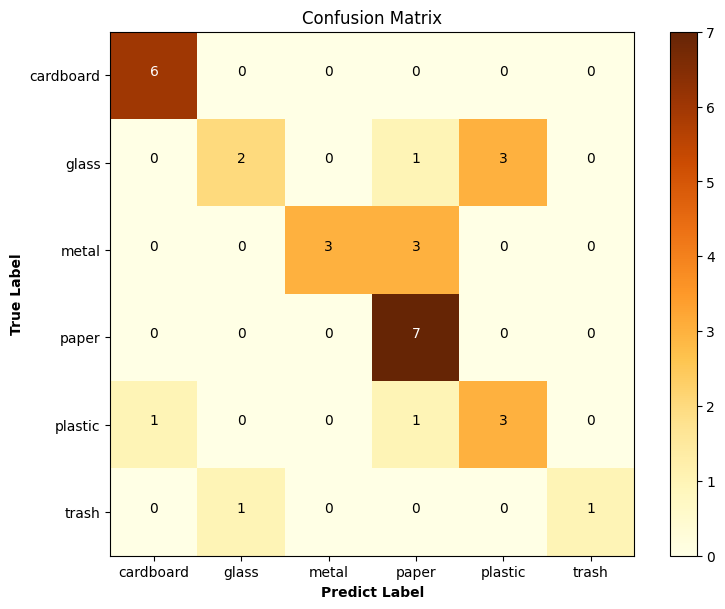

In [ ]:
cm = confusion_matrix(y_test, y_pred)

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):

  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  plt.figure(figsize=(8, 6))
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=0)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
  plt.tight_layout()
  plt.ylabel('True Label', fontweight="bold")
  plt.xlabel('Predict Label', fontweight="bold")

plot_confusion_matrix(cm, waste_labels.keys(), title='Confusion Matrix', cmap=plt.cm.YlOrBr)


## **7. Testing the Model**

In [ ]:
waste_labels = {0: 'cardboard', 1 : 'glass', 2 : 'metal', 3 : 'paper', 4 : 'plastic', 5 : 'trash'}

In [ ]:
def model_testing(path):
  img = image.load_img(path, target_size=(target_size))
  img = image.img_to_array(img, dtype=np.uint8)
  img = np.array(img) / 255.0
  p = model.predict(img.reshape(1, 224, 224, 3))
  predicted_class = np.argmax(p[0])

  return img, p, predicted_class


In [ ]:
def view_classify(img, ps, true_label, predicted_label, predicted_prob):
    fig, (ax1, ax2) = plt.subplots(figsize=(10, 6), ncols=2)

    ax1.imshow(img.squeeze())
    ax1.axis('off')
    ax1.set_title(f'True: {true_label}\nPredicted: {predicted_label}\nProb: {predicted_prob:.4f}')

    ax2.barh(list(waste_labels.values()), ps[0])
    ax2.set_aspect(0.1)
    ax2.set_yticks(range(6))
    ax2.set_yticklabels(list(waste_labels.values()))
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
True Label: cardboard, Predicted Label: cardboard, Predicted Probability: 0.9425
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
True Label: glass, Predicted Label: glass, Predicted Probability: 0.4511
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
True Label: metal, Predicted Label: paper, Predicted Probability: 0.4683
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
True Label: paper, Predicted Label: paper, Predicted Probability: 0.9320
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
True Label: plastic, Predicted Label: plastic, Predicted Probability: 0.2977
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
True Label: trash, Predicted Label: trash, Predicted Probability: 0.3723


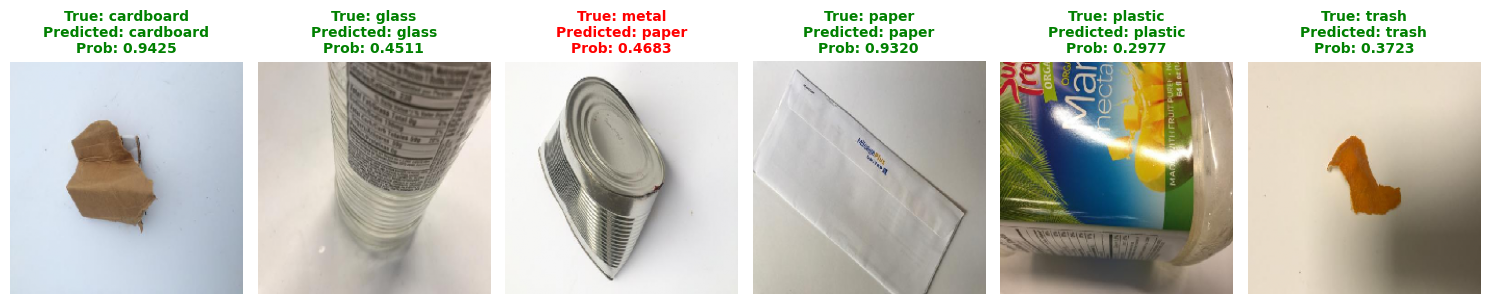

In [ ]:
def predict_random_samples(model, dir_path, num_classes=6):
  model.load_weights('mymodel.keras')

  results = []

  class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

  for class_name in class_names:
    class_path = os.path.join(dir_path, class_name)

    image_files = [f for f in os.listdir(class_path)
                  if f.endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
      print(f"No images found for class : {class_name}")
      continue

    random_image = random.choice(image_files)
    image_path = os.path.join(class_path, random_image)

    img, ps, predicted_class = model_testing(image_path)

    predicted_label = waste_labels[predicted_class]
    true_label = class_name
    predicted_prob = np.max(ps[0])

    results.append({
            'img': img,
            'true_label': true_label,
            'predicted_label': predicted_label,
            'predicted_prob': predicted_prob
        })

    print(f"True Label: {true_label}, Predicted Label: {predicted_label}, "
              f"Predicted Probability: {predicted_prob:.4f}")

  fig, axes = plt.subplots(1, 6, figsize=(15, 5))
  axes = axes.ravel()

  for idx, result in enumerate(results):
      axes[idx].imshow(result['img'].squeeze())
      axes[idx].axis('off')

      title_color = 'green' if result['true_label'] == result['predicted_label'] else 'red'

      axes[idx].set_title(
          f"True: {result['true_label']}\n"
          f"Predicted: {result['predicted_label']}\n"
          f"Prob: {result['predicted_prob']:.4f}",
          fontsize=10,
          color=title_color,
          fontweight='bold'
        )

  plt.tight_layout()
  plt.show()

predict_random_samples(model, dir_path, num_classes=6)
